Notebook to plot the scores and get the model ranking:

In [1]:
import sys
import colorsys
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd 
import matplotlib as mpl
from matplotlib import cm 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
from shapely.geometry import Polygon, MultiPolygon
from itertools import product 

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12


Map models name to models_id:

In [ ]:
dict_models_name = {157: 'UERJ-SARIMAX-2', 156: 'Dengue oracle M2', 155: 'Dengue Oracle M1', 135:'GHR Model', 
                    133:'Chronos-Bolt', 158: 'Cornell PEH', 143: 'Model fourier-\n gravidade', 144:'Beat it', 150: 'LNCC-AR_p-1', 
        145: 'CNNLSTM' , 141: 'Kaust Geohealth', 136: 'Imperial-TFT Model', 137: 'LSTM-RF model', 
                    138: 'TSMixer ZKI-PH4', 154: 'LNCC-SURGE-1', 152: 'LNCC-CLIDENGO-1', 134: 'ISI_Dengue_Model', 108:'IMPA-TECH'} 

dict_name_models = {v: k for k, v in dict_models_name.items()}

In [3]:
keys = [157, 156, 155, 135, 133, 158, 143, 144, 150, 
        145, 141, 136, 137, 138, 154, 152, 134, 108]

n = len(keys)

# Gerar cores bem espaçadas no círculo HSV
def generate_vibrant_colors(n, s=0.8, v=0.9):
    hues = np.linspace(0, 1, n, endpoint=False)
    colors = [colorsys.hsv_to_rgb(h, s, v) for h in hues]
    return colors

colors = generate_vibrant_colors(n)

# Criar dict {key: color} garantindo que nenhuma cor é cinza/preto
color_palette = {k: colors[i] for i, k in enumerate(dict_models_name.values())}

In [4]:
df_metrics = pd.read_csv('results/metrics_wis.csv')
df_metrics = df_metrics.loc[(df_metrics.model!=141) & (df_metrics.state != 'ES')]
df_metrics.head()

,model,state,validation_test,WIS,WIS_peak
0,108,AC,1,134.356863,167.219037
1,108,AC,2,160.594527,261.428763
2,108,AC,3,125.106428,232.815888
3,108,AC,all,140.932304,NaN
4,108,AL,1,1310.101366,842.820420


In [5]:
df_metrics.model.unique()

array([108, 133, 134, 135, 136, 137, 138, 143, 144, 145, 150, 152, 154,
       155, 156, 157, 158])

In [6]:
len(df_metrics.model.unique())

17

In [7]:
df_metrics.validation_test.unique()

array(['1', '2', '3', 'all'], dtype=object)

In [8]:
def compute_rank(df_metrics, state, vt, columns = ['WIS', 'WIS_peak']): 
    '''
    Rank the models based on the values of each column.
    '''
    df_slice = df_metrics.loc[
                (df_metrics.state == state) & (df_metrics.validation_test == vt),
                ['model'] + list(columns)
            ].copy()
    
    # Rank columns
    df_slice[f'rank_WIS_{state}_{vt}'] = df_slice['WIS'].rank(method="dense", ascending=True)

    if 'WIS_peak' in columns:
        df_slice[f'rank_WIS_peak_{state}_{vt}'] = df_slice['WIS_peak'].rank(method="dense", ascending=True)
    
        # Keep only model and ranks
        df_slice = df_slice.set_index('model')[
                    [f'rank_WIS_{state}_{vt}', f'rank_WIS_peak_{state}_{vt}']]
    else: 
        df_slice = df_slice.set_index('model')[
                    [f'rank_WIS_{state}_{vt}']]
        
    return df_slice

def get_rank_by_state(df_rank, state):
    '''
    Get the model rank for each state based on each validation test and each score computed. 
    '''
    df_f = df_rank.filter(like=state, axis=1)

    df_f[f'rank_{state}'] = (1/df_f[df_f.columns]).sum(axis=1).rank(method="dense", ascending=False)

    return df_f[[f'rank_{state}']]

def get_best_models_state(df_metrics, state, validation_tests=['1','2','3'], n_models = 5, columns = ['WIS', 'WIS_peak']): 
    '''
    Get an ordered list of the best models by state. 
    '''
    rank_dfs = []

    for vt in validation_tests:
        df_slice = compute_rank(df_metrics, state, vt, columns)
    
        rank_dfs.append(df_slice)

    df_ranks = pd.concat(rank_dfs, axis=1)

    return get_rank_by_state(df_ranks, state).sort_values(by = f'rank_{state}', ascending = True).head(n_models).index
    

def get_best_models_region(df_metrics, states, validation_tests, n_models = 5, columns = ['WIS', 'WIS_peak']): 
    '''
    Get the model rank of each region based on the values from each validation for each state in the region.
    '''
        
    rank_dfs = []

    for state in states:
        for vt in validation_tests:
            df_slice = compute_rank(df_metrics, state, vt, columns)    
            rank_dfs.append(df_slice)
    
    # Concatenate all by columns
    df_ranks = pd.concat(rank_dfs, axis=1)

    df_ranks['rank_final'] = (1/df_ranks[df_ranks.columns]).sum(axis=1).rank(method="dense", ascending=False)
    #df_ranks['rank_final'] = (df_ranks[df_ranks.columns]).mean(axis=1).rank(method="dense", ascending=True)

    return df_ranks.sort_values(by= 'rank_final').head(n_models).index

def get_best_models_region_from_state(df_metrics, states, validation_tests, n_models = 5, columns = ['WIS', 'WIS_peak']): 
    '''
    Get the model rank of each region based on the rank of each state.
    '''

    state_ranks = []

    for state in states:
        
        rank_dfs = []

        for vt in validation_tests:
            df_slice = compute_rank(df_metrics, state, vt, columns)
    
            rank_dfs.append(df_slice)

        df_ranks = pd.concat(rank_dfs, axis=1)

        state_ranks.append(get_rank_by_state(df_ranks, state))

    df_rank_region = pd.concat(state_ranks, axis=1)

    df_rank_region['rank_final'] = (1/df_rank_region[df_rank_region.columns]).sum(axis=1).rank(method="dense", ascending=False)
    #df_rank_region['rank_final'] = (df_rank_region[df_rank_region.columns]).mean(axis=1).rank(method="dense", ascending=True)

    return df_rank_region.sort_values(by= 'rank_final').head(n_models).index  
    

def get_best_models_region_all(df_metrics, states, n_models = 5, column = 'WIS'): 
    '''
    Get the model rank of each region based on the rank of each state.
    '''
    df_rank = pd.DataFrame()

    for state in states: 
    
        df_r = df_metrics.loc[(df_metrics.validation_test == 'all') & (df_metrics.state == state)].sort_values(by = column).reset_index(drop=True)[['model']]
        df_r[f'rank_{state}'] = np.arange(1, 18)
        df_r.set_index('model', inplace = True)
    
        df_rank  = pd.concat([df_rank, df_r], axis =1)
    
    df_rank['rank_final'] = (1/df_rank[df_rank.columns]).sum(axis=1).rank(method="dense", ascending=False)
    
    return df_rank.sort_values(by= 'rank_final').head(n_models).index  


Best model using S1,... S6

In [9]:
best_models = []
for state in df_metrics.state.unique():
    best_models.append(get_best_models_state(df_metrics.dropna(), state= state)[0]) 

df_bm_st = pd.DataFrame()

df_bm_st['state'] = df_metrics.state.unique()
df_bm_st['best_model']= best_models

df_bm_st.head()

,state,best_model
0,AC,158
1,AL,135
2,AM,150
3,AP,157
4,BA,145


Best model using the WIS in all the three validation sets concatenated: 

In [10]:
df_s = df_metrics.loc[df_metrics.validation_test == 'all']

df_s = df_s.loc[df_s.groupby("state")["WIS"].idxmin()][['model', 'state']].rename(columns = {'model':'best_model_all'})

df_s.head()

,best_model_all,state
847,144,AC
323,135,AL
855,144,AM
751,143,AP
439,136,BA


In [11]:
df_bm_st = df_s

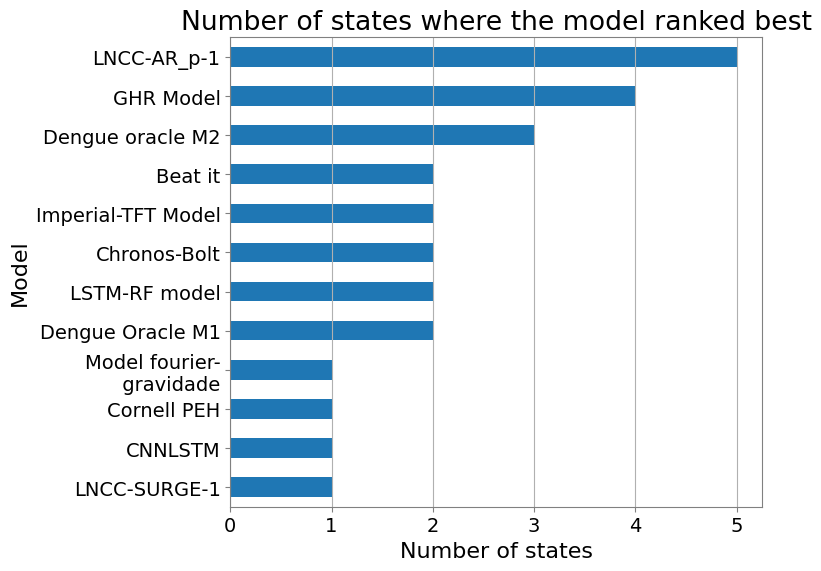

In [12]:
df_bm_st['best_model_all'] = df_bm_st.best_model_all.replace(dict_models_name)
counts = df_bm_st.best_model_all.value_counts()

# Plot horizontal bar chart
counts.plot(kind="barh", figsize=(8,6))

plt.ylabel("Model")
plt.xlabel("Number of states")
plt.title("Number of states where the model ranked best")
plt.gca().invert_yaxis()  # optional: puts the highest bar at the top
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('figures/count_best_models_state.png', dpi=450, bbox_inches='tight')
plt.show()

df_bm_st['best_model'] = df_bm_st.best_model.replace( dict_models_name)
counts = df_bm_st.best_model.value_counts()

# Plot
counts.plot(kind="bar", figsize=(8,6))

plt.xlabel("Model")
plt.ylabel("Number of states")
plt.title("Number of states where the model ranked best")
plt.xticks(rotation=45, ha="center")
plt.grid(axis = 'y')
plt.tight_layout()
plt.savefig('figures/count_best_models_state.png', dpi = 450, bbox_inches = 'tight')
plt.show()


In [13]:
def remove_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)  # mantém só o contorno externo
    elif geom.geom_type == "MultiPolygon":
        # acessa cada polígono dentro do MultiPolygon
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    else:
        return geom

In [14]:
df_muni = gpd.read_file('/Users/eduardoaraujo/Documents/sprint_data_2025/shape_muni.gpkg')

df_muni["geometry"] = df_muni.buffer(0)

df_uf = df_muni.dissolve(by="uf")

df_uf["geometry"] = df_uf["geometry"].apply(remove_holes)

df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)

# reset index if you want 'uf' back as a column
df_uf = df_uf.reset_index()

df_uf_m = df_uf.merge(df_bm_st, left_on = 'uf', right_on = 'state')

df_uf_m.head()

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_24320/2392916923.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)


,uf,geometry,geocode,geocode_name,uf_code,best_model_all,state
0,AC,"POLYGON ((-70.51515 -7.79238, -70.05498 -7.845...",1200013,Acrelândia,12,Beat it,AC
1,AL,"MULTIPOLYGON (((-38.23759 -9.3298, -38.23759 -...",2700102,Água Branca,27,GHR Model,AL
2,AM,"POLYGON ((-72.37321 -4.83344, -72.37321 -4.833...",1300029,Alvarães,13,Beat it,AM
3,AP,"MULTIPOLYGON (((-54.87625 2.42669, -54.87625 2...",1600055,Serra do Navio,16,Model fourier-\n gravidade,AP
4,BA,"MULTIPOLYGON (((-46.57715 -11.36086, -46.57715...",2900108,Abaíra,29,Imperial-TFT Model,BA


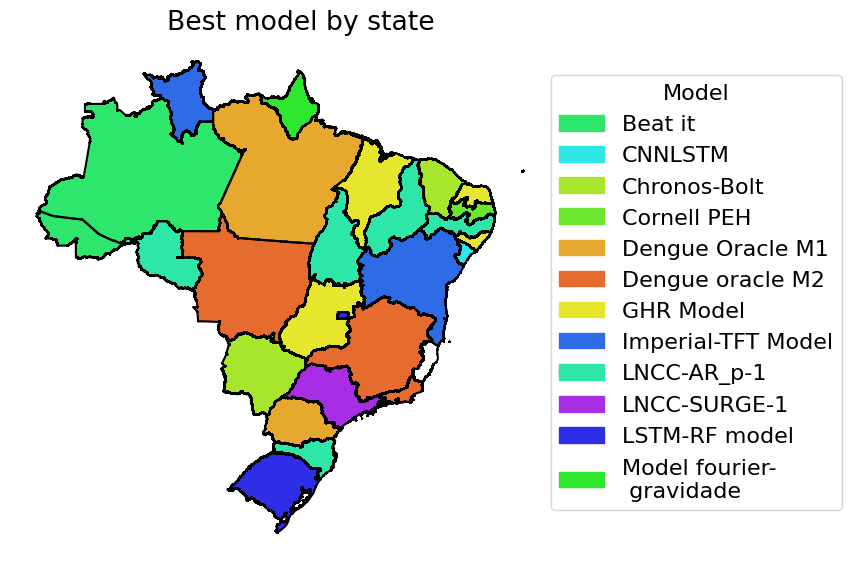

In [15]:
_, ax = plt.subplots(figsize = (7.5, 7.5))

handles = []  # aqui guardamos os patches da legenda

for model in np.sort(df_uf_m.best_model_all.unique()): 

    df_ = df_uf_m.loc[df_uf_m.best_model_all == model]
    
    #model = df_.best_model.values[0]

    df_.plot(color = color_palette[model], label = model, ax=ax)

    if not any(h.get_label() == model for h in handles):
        handles.append(mpatches.Patch(color=color_palette[model], label=model))

df_uf.boundary.plot(ax=ax, color = 'black')
ax.axis('off')

ax.legend(handles = handles, title = 'Model', bbox_to_anchor = (1.45, 0.95))

ax.set_title('Best model by state')

plt.savefig('figures/map_best_model.png', dpi = 400, bbox_inches = 'tight')
plt.show()

Rank of the best model by state in each validation test:

In [16]:
df_bm_st.head()

,best_model_all,state
847,Beat it,AC
323,GHR Model,AL
855,Beat it,AM
751,Model fourier-\n gravidade,AP
439,Imperial-TFT Model,BA


In [17]:
df_bm_st.to_csv('results/best_model_by_state.csv')

In [25]:
state = 'AC'

model = df_bm_st.loc[df_bm_st.state == state].best_model_all.values[0]
dict_name_models[model]

144

In [37]:
def get_rank_by_model(df_metrics, state, model, val_test = '1'):    
    df_ = df_metrics.loc[(df_metrics.validation_test == val_test) & 
                (df_metrics.state == state)].sort_values(by = 'WIS')

    df_['rank'] = np.arange(1, 18)

    return df_.loc[df_.model == dict_name_models[model]]['rank'].values[0]

In [40]:
get_rank_by_model(df_metrics, 'AC', model, '3')

3

In [56]:
df_rank_by_model_st = pd.DataFrame()

for st in df_metrics.state.unique(): 
    
    model = df_bm_st.loc[df_bm_st.state == st].best_model_all.values[0]

    for val in ['1', '2', '3']:

        rank = get_rank_by_model(df_metrics, st, model, val)

        df_rank_by_model_st = pd.concat([df_rank_by_model_st,
                    
                    pd.DataFrame([[model,st, val,rank]],
                                 columns = ['model', 'state', 
                                            'val_test', 'rank'])], 
                                            ignore_index = True)
        
df_rank_by_model_st['val_test'] = df_rank_by_model_st['val_test'].replace(
    {'1': 2023, '2': 2024, '3': 2025}
) 
df_rank_by_model_st


/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_10477/2511679501.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_rank_by_model_st['val_test'] = df_rank_by_model_st['val_test'].replace(


,model,state,val_test,rank
0,Beat it,AC,2023,5
1,Beat it,AC,2024,2
2,Beat it,AC,2025,3
3,GHR Model,AL,2023,2
4,GHR Model,AL,2024,5
...,...,...,...,...
73,LNCC-SURGE-1,SP,2024,2
74,LNCC-SURGE-1,SP,2025,5
75,LNCC-AR_p-1,TO,2023,1
76,LNCC-AR_p-1,TO,2024,2


In [57]:
df_pv = df_rank_by_model_st.pivot(index = 'val_test', columns = 'state', values = 'rank')

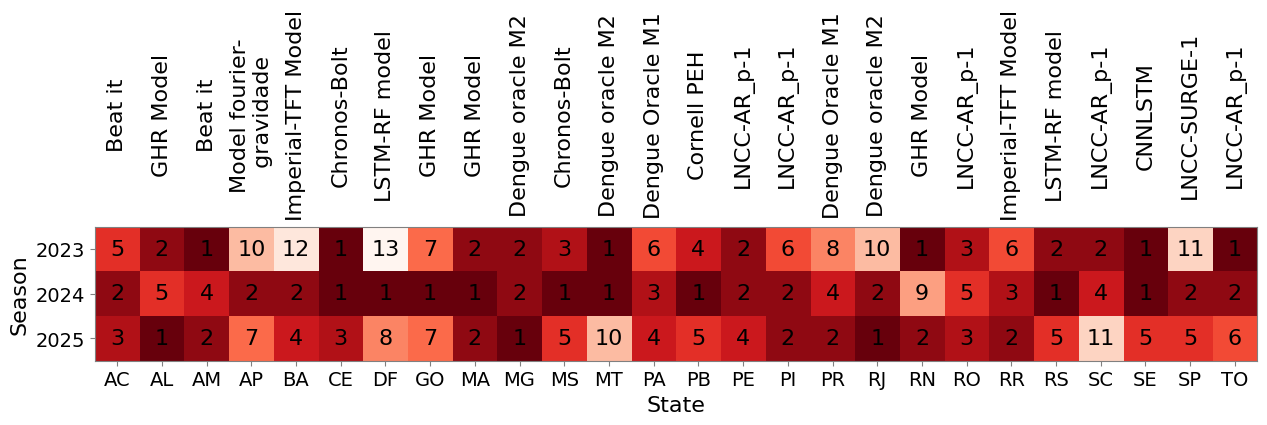

In [82]:
fig, ax = plt.subplots(figsize = (15, 3))

# Show as image
im = ax.imshow(df_pv.values, cmap="Reds_r")

# Add labels
ax.set_xticks(np.arange(df_pv.shape[1]))
ax.set_yticks(np.arange(df_pv.shape[0]))
ax.set_xticklabels(df_pv.columns)
ax.set_yticklabels(df_pv.index)

for i in range(df_pv.shape[0]):
    for j in range(df_pv.shape[1]):
        text = ax.text(j, i, df_pv.iloc[i, j],
                       ha="center", va="center", color="black")

for j in range(df_pv.shape[1]):
    
    model = df_rank_by_model_st.loc[df_rank_by_model_st.state == df_pv.columns[j]].model.values[0]

    text = ax.text(j, -3, model,
                       ha="center", va="center", color="black", 
                       rotation=90)
        
ax.set_xlabel('State')
ax.set_ylabel('Season')

plt.savefig('figures/rank_best_models.png', dpi = 400, bbox_inches = 'tight')
plt.show()

In [65]:
df_pv.shape

(3, 26)

'LNCC-AR_p-1'

In [60]:
df_rank_by_model_st

,model,state,val_test,rank
0,Beat it,AC,2023,5
1,Beat it,AC,2024,2
2,Beat it,AC,2025,3
3,GHR Model,AL,2023,2
4,GHR Model,AL,2024,5
...,...,...,...,...
73,LNCC-SURGE-1,SP,2024,2
74,LNCC-SURGE-1,SP,2025,5
75,LNCC-AR_p-1,TO,2023,1
76,LNCC-AR_p-1,TO,2024,2


### Melhor modelo por região: 

In [16]:
get_best_models_region_all(df_metrics, ['RS', 'SC', 'PR'], n_models = 5)

Index([155, 137, 150, 144, 157], dtype='int64', name='model')

In [17]:
dict_regions = {
'Nordeste': ['AL', 'BA', 'CE','MA', 'PB', 'PE', 'PI', 'SE', 'RN'],
'Sudeste' : ['SP', 'MG', 'RJ'],
'Sul'  : ['RS', 'SC', 'PR'],
'Centro-Oeste' : ['DF', 'GO', 'MT', 'MS'],
'Norte' : ['AM', 'AP', 'TO', 'RR', 'RO' ,'AC', 'PA']
}

In [18]:
df_reg = pd.DataFrame()

for reg in dict_regions.keys(): 
    
    df_reg[reg] = get_best_models_region_all(df_metrics, 
                                         dict_regions[reg], 
                                         n_models = 5).values

df_reg = df_reg.replace(dict_models_name)

df_reg.head()

,Nordeste,Sudeste,Sul,Centro-Oeste,Norte
0,GHR Model,Dengue oracle M2,Dengue Oracle M1,GHR Model,LNCC-AR_p-1
1,LNCC-AR_p-1,LNCC-SURGE-1,LSTM-RF model,LSTM-RF model,Beat it
2,Cornell PEH,Dengue Oracle M1,LNCC-AR_p-1,Dengue oracle M2,Imperial-TFT Model
3,Imperial-TFT Model,GHR Model,Beat it,UERJ-SARIMAX-2,Dengue Oracle M1
4,CNNLSTM,Cornell PEH,UERJ-SARIMAX-2,Chronos-Bolt,Cornell PEH


In [19]:
df_reg.to_csv('results/best_models_by_region.csv')

## Plot heatmaps by regions: 

In [20]:
def apply_colormap(data, colormaps):
    '''
    Function to color the table based on its values. 
    '''
    rows, cols = data.shape
    colored_data = np.zeros((rows, cols, 3))  # Store RGB values

    for i in range(cols):
        norm = plt.Normalize(vmin=data[:, i].min(), vmax=data[:, i].max())  # Normalize per column
        cmap = plt.get_cmap(colormaps[i])
        colored_data[:, i, :] = cmap(norm(data[:, i]))[:, :3]  # Apply colormap, exclude alpha
    return colored_data
    

def plot_heat(ax, df, year, metric, label, fig = None, legend = False, colorbar_loc = [0.92, 0.15, 0.02, 0.7], highlight = True):
    '''
    Function to create a heatmap as a Matplotlib figure and highlight the minimum value in each column if `highlight=True`.
    '''
    df_ = df.pivot(columns = 'state', index = 'model', values = metric)

    xlabels = df_.columns
    ylabels = df_.index.values.astype(str)

    if metric == 'log_score':
        colormaps = ['Reds']*len(xlabels)
    else:
        colormaps = ['Reds_r']*len(xlabels)
    #print(len(colormaps))
    df_ = df_.values
    # Apply colormap
    colored_data = apply_colormap(df_, colormaps)

    # Plot heatmap
    img = ax.imshow(colored_data, aspect='auto')  # Show the colored matrix

    if legend: 
        norm = plt.Normalize(vmin=0, vmax=1)
        cmap = plt.get_cmap('Reds')
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax = fig.add_axes(colorbar_loc)
        cbar = fig.colorbar(sm, cax=cax, ticks=[], label='')
        cbar.ax.text(0.5, -0.05, 'Worst', va='center', ha='center', fontsize=FONT, transform=cbar.ax.transAxes)
        cbar.ax.text(0.5, 1.05, 'Better', va='center', ha='center', fontsize=FONT, transform=cbar.ax.transAxes)
        
    # Add text labels (data values) to each cell
    rows, cols = df_.shape
    for i in range(rows):
        for j in range(cols):

            r, g, b = colored_data[i, j]
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = 'black' if luminance > 0.5 else 'white'

            ax.text(j, i, f"{df_[i, j]:.2f}", ha='center', va='center', 
                color=text_color, fontsize=FONT)

    if highlight: 
    #  Destacar menor valor de cada coluna com um retângulo
        for j in range(cols):
            i_min = np.argmin(df_[:, j])  # linha do menor valor na coluna j
            rect = patches.Rectangle((j-0.5, i_min-0.5), 1, 1, 
                                     fill=False, edgecolor='limegreen', linewidth=2.5)
            ax.add_patch(rect)
    
        pad = 0.1  # pode aumentar se quiser mais espaço
        ax.set_xlim(-0.5 - pad, cols - 0.5 + pad)
        ax.set_ylim(rows - 0.5 + pad, -0.5 - pad)
        
    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels)

    ax.set_yticks(np.arange(len(ylabels)))
    ax.set_yticklabels(ylabels)
    
    ax.set_frame_on(False)
    ax.set_xlabel('State')
    ax.set_ylabel('Model')
    ax.tick_params(axis='y', labelrotation=0)

    if metric == 'WIS':
        lb_metric = 'WIS'
    if metric == 'WIS_peak':
        lb_metric = 'WIS (around the peak)'
    if metric == 'crps':
        lb_metric = 'CRPS'
    if metric == 'log_score':
        lb_metric = 'Log Score'
    if metric == 'interval_score':
        lb_metric = 'Interval Score'
        
    ax.set_title(f'{label} - {year} ({lb_metric})')
    

In [21]:
def order_dataframe(df_metrics, n_models_region): 
    '''
    Function to order the DataFrame based on a list of models in a specific order.
    '''
    
    df_sm = df_metrics.loc[df_metrics.model.isin(n_models_region)].copy()
    
    df_sm["model"] = pd.Categorical(df_sm["model"], categories=n_models_region, ordered=True)
    
    # Ordenar
    df_sm = df_sm.sort_values("model").reset_index(drop=True)

    return df_sm

In [22]:
brazil_macroregions = {
    "North": ["AC", "AP", "AM", "PA", "RO", "RR", "TO"],
    "Northeast": ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"],
    "Midwest": ["DF", "GO", "MT", "MS"],
    "Southeast": ["MG", "RJ", "SP"],
    "South": ["PR", "RS", "SC"]
}

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/2800526407.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


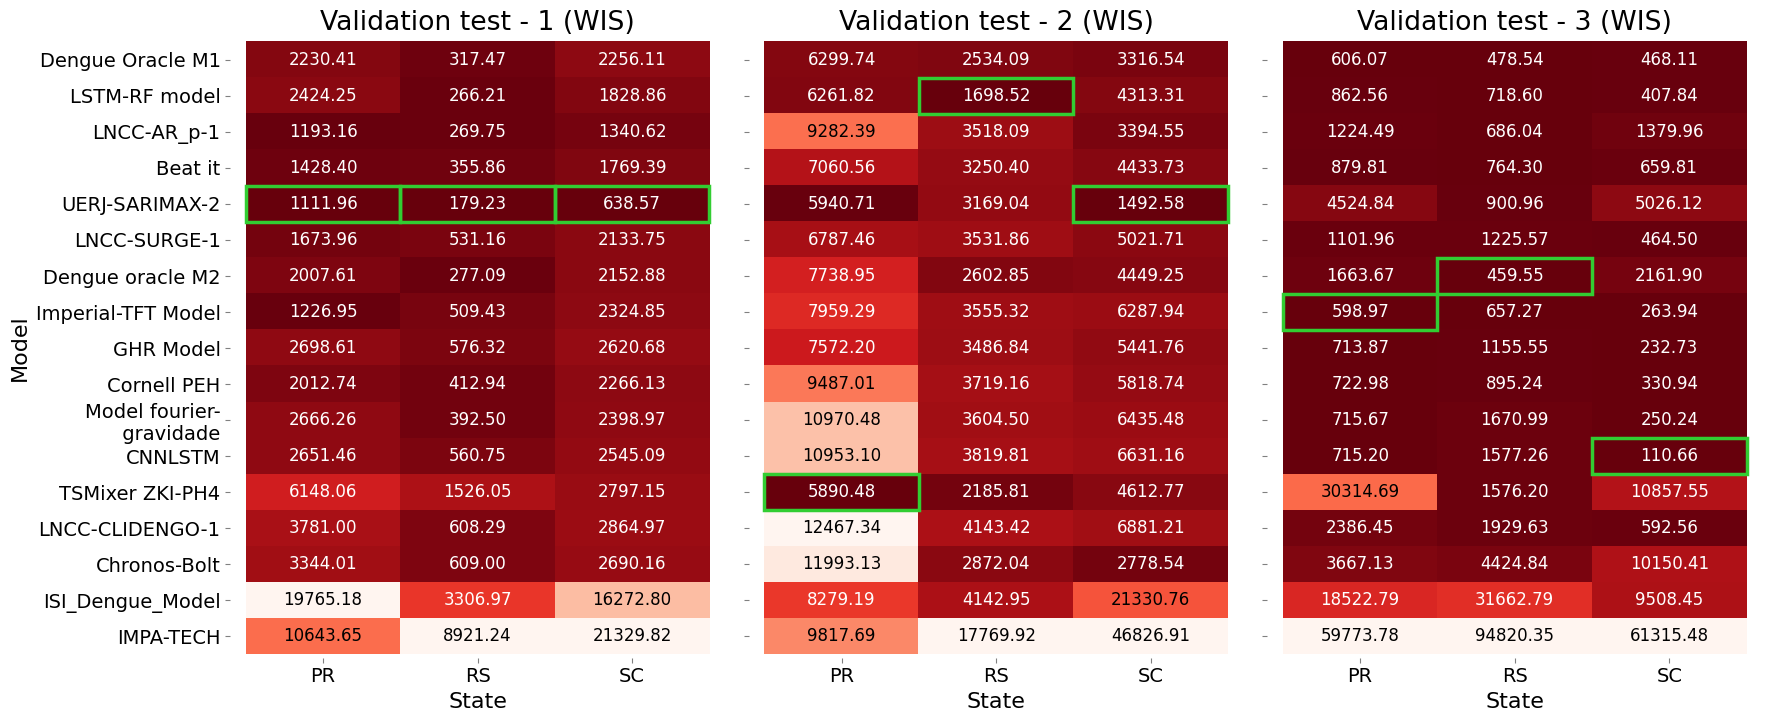

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/2800526407.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


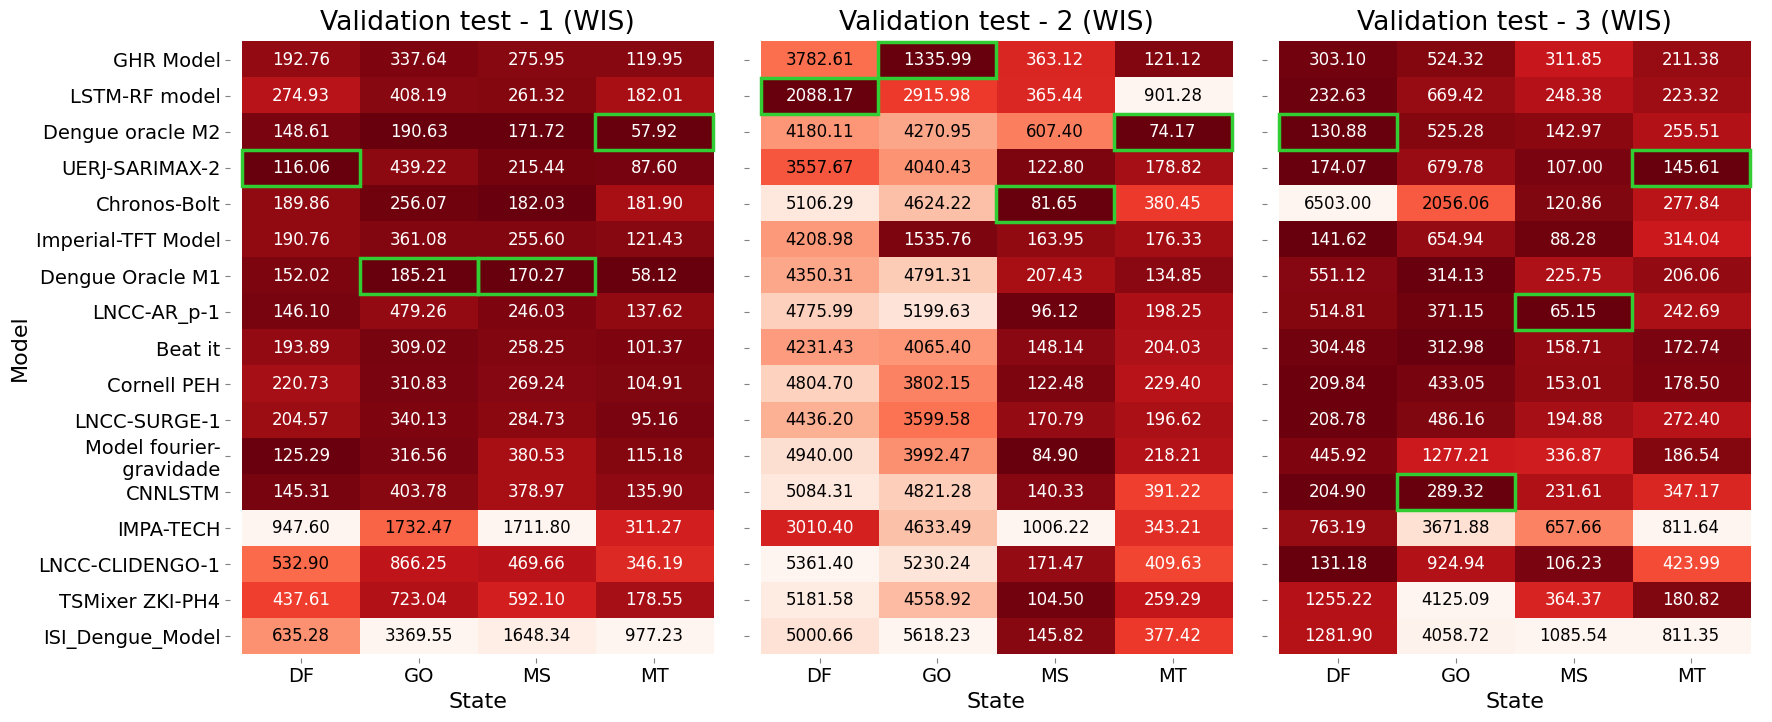

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/2800526407.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


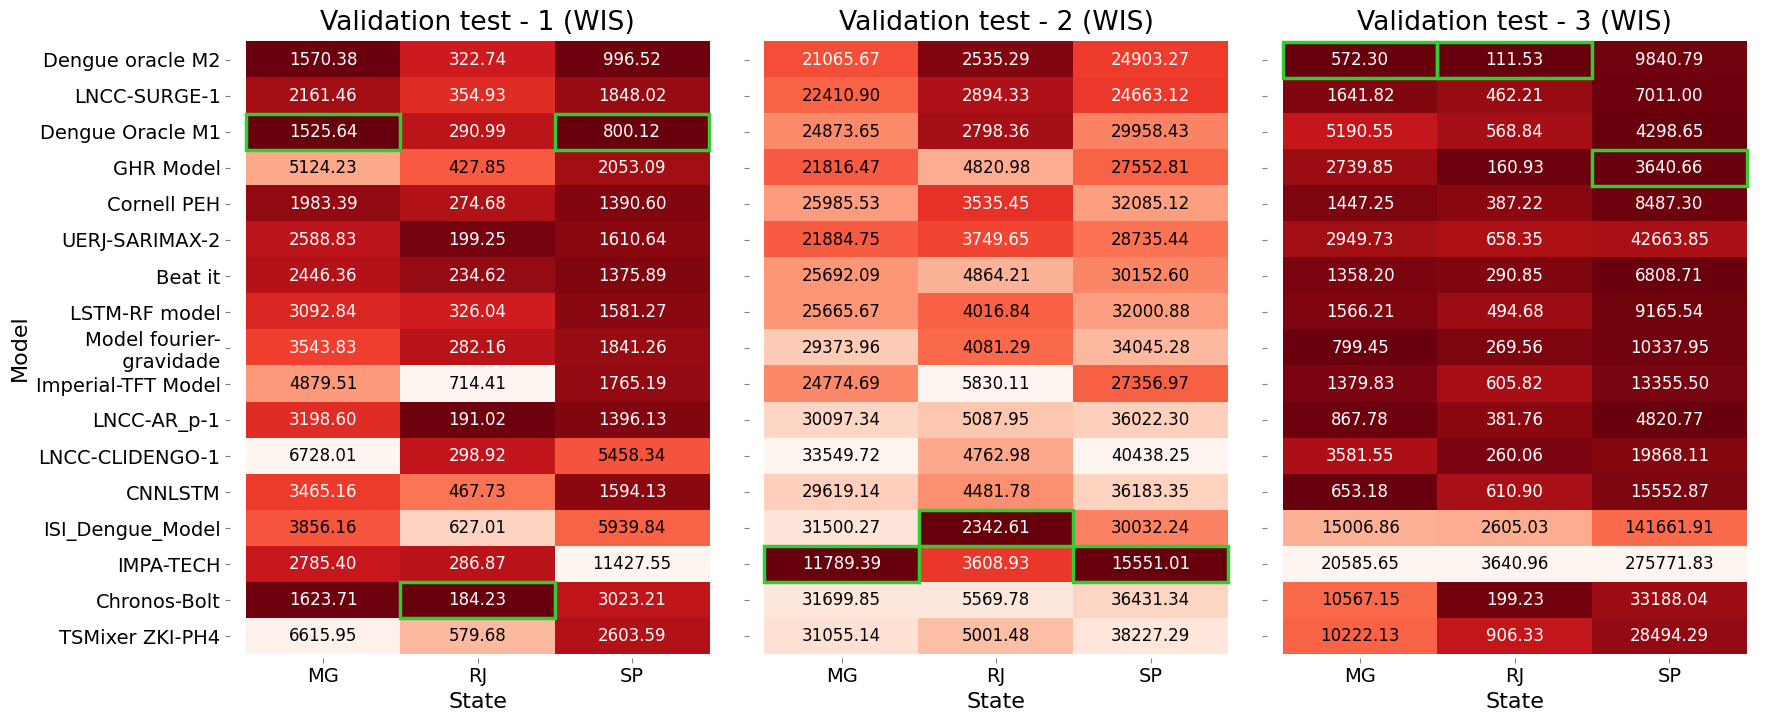

In [23]:
validation_tests = ['1', '2', '3']

for reg in ['South', 'Midwest', 'Southeast']: 
    
    states = brazil_macroregions[reg]

    #top_5_models = get_best_models_region(df_metrics, states, validation_tests, n_models = 5)

    n_models_region = get_best_models_region_all(df_metrics, states, n_models = 18)

    df_sm = order_dataframe(df_metrics, n_models_region)

    df_sm['model'] = df_sm['model'].replace(dict_models_name)

    _,ax = plt.subplots(1,3, figsize = (18, 7.5), sharey= True)

    plot_heat(ax[0], df_sm.loc[(df_sm.validation_test == '1') & (df_sm.state.isin(states))], '1', 'WIS', 'Validation test')
    
    plot_heat(ax[1], df_sm.loc[(df_sm.validation_test == '2') & (df_sm.state.isin(states))], '2', 'WIS', 'Validation test')
    
    plot_heat(ax[2], df_sm.loc[(df_sm.validation_test == '3') & (df_sm.state.isin(states))], '3', 'WIS', 'Validation test')

    ax[1].set_ylabel('')
    ax[2].set_ylabel('')
    plt.tight_layout()

    plt.savefig(f'figures/all_models_WIS_{reg.lower()}.png', dpi = 400, bbox_inches = 'tight')

    plt.show()
    
        

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/1643086223.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


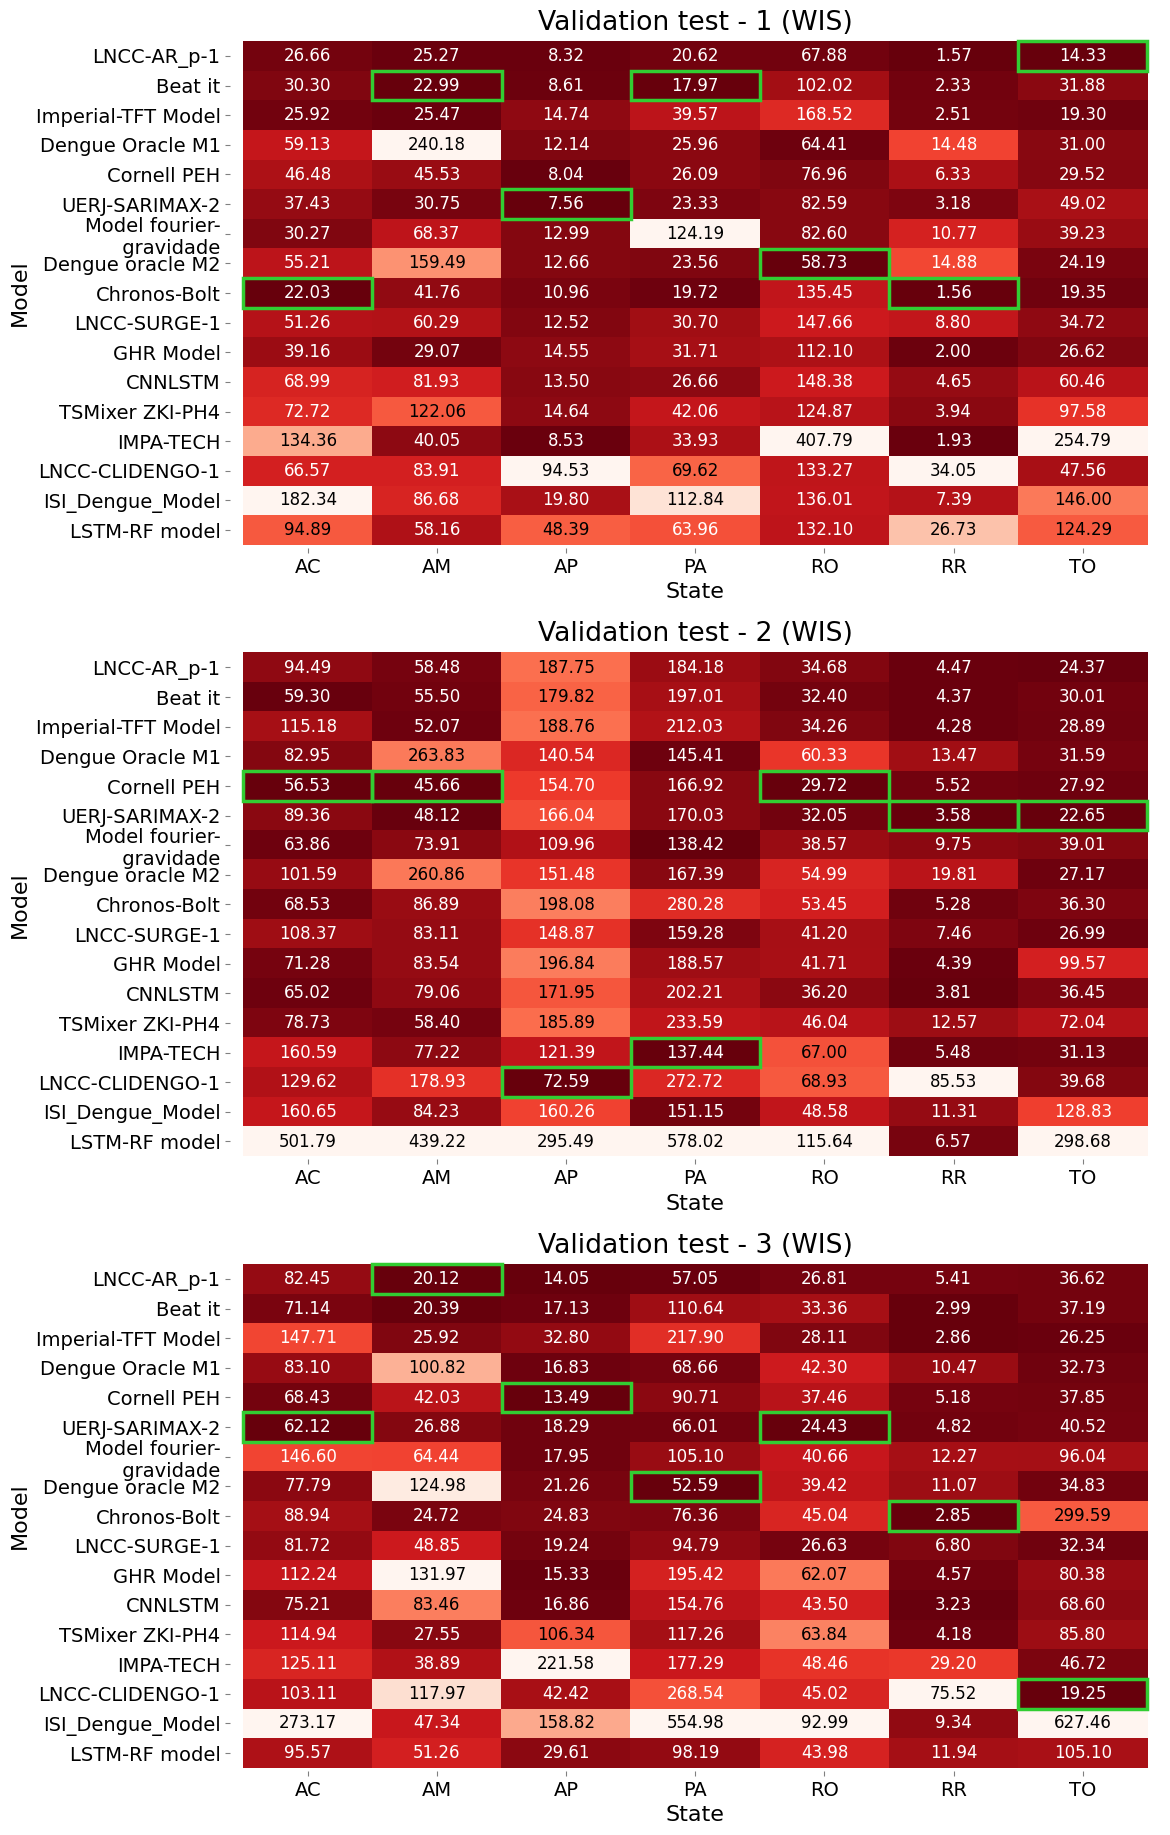

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/1643086223.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


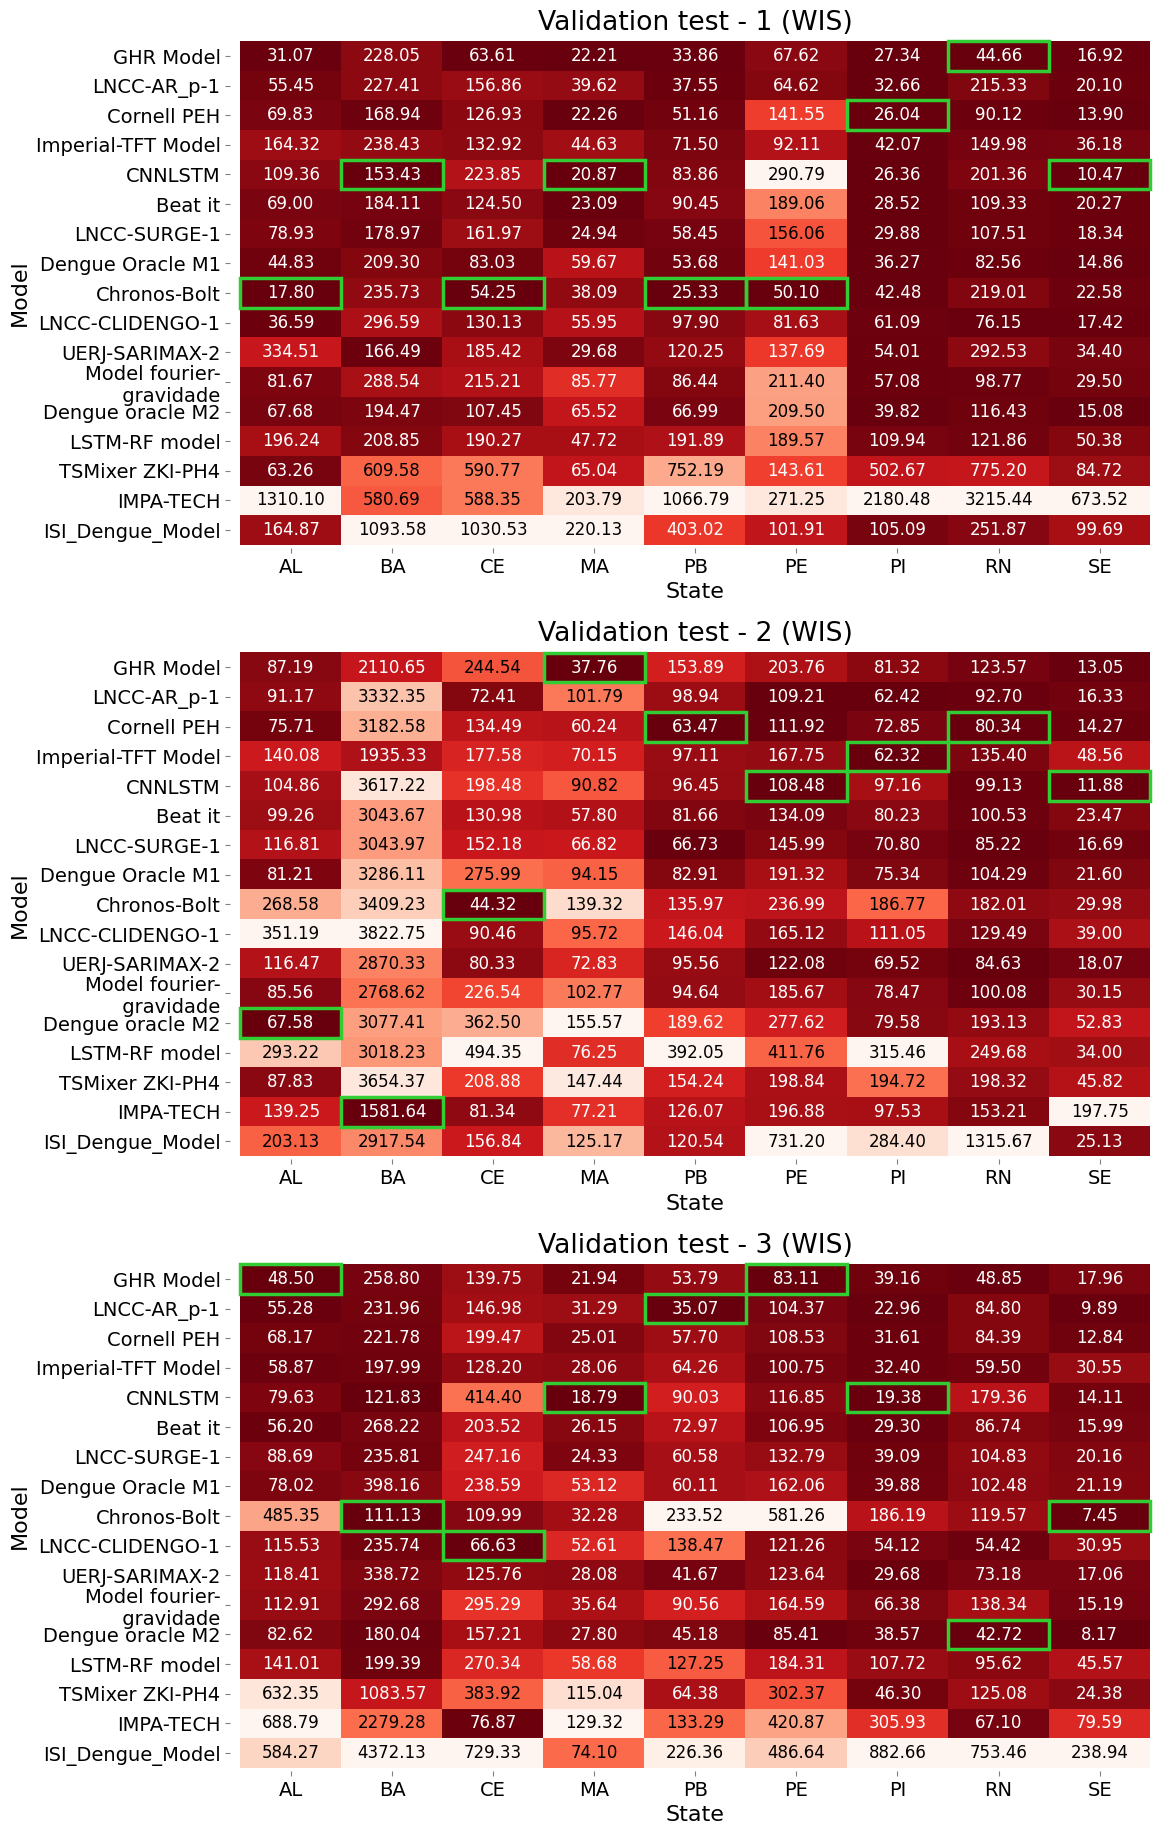

In [24]:
for reg in ['North', 'Northeast']: 
    
    states = brazil_macroregions[reg]

    #top_5_models = get_best_models_region(df_metrics, states, validation_tests, n_models = 5)

    n_models_region = get_best_models_region_all(df_metrics, states, n_models = 18)

    df_sm = order_dataframe(df_metrics, n_models_region)

    df_sm['model'] = df_sm['model'].replace(dict_models_name)


    _,ax = plt.subplots(3, 1, figsize = (12, 22.5))

    plot_heat(ax[0], df_sm.loc[(df_sm.validation_test == '1') & (df_sm.state.isin(states))], '1', 'WIS', 'Validation test')
    
    plot_heat(ax[1], df_sm.loc[(df_sm.validation_test == '2') & (df_sm.state.isin(states))], '2', 'WIS', 'Validation test')
    
    plot_heat(ax[2], df_sm.loc[(df_sm.validation_test == '3') & (df_sm.state.isin(states))], '3', 'WIS', 'Validation test')
    
    plt.savefig(f'figures/all_models_WIS_{reg.lower()}.png', dpi = 400, bbox_inches = 'tight')

    plt.show()
    

Top 5 models: 

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/11860109.py:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


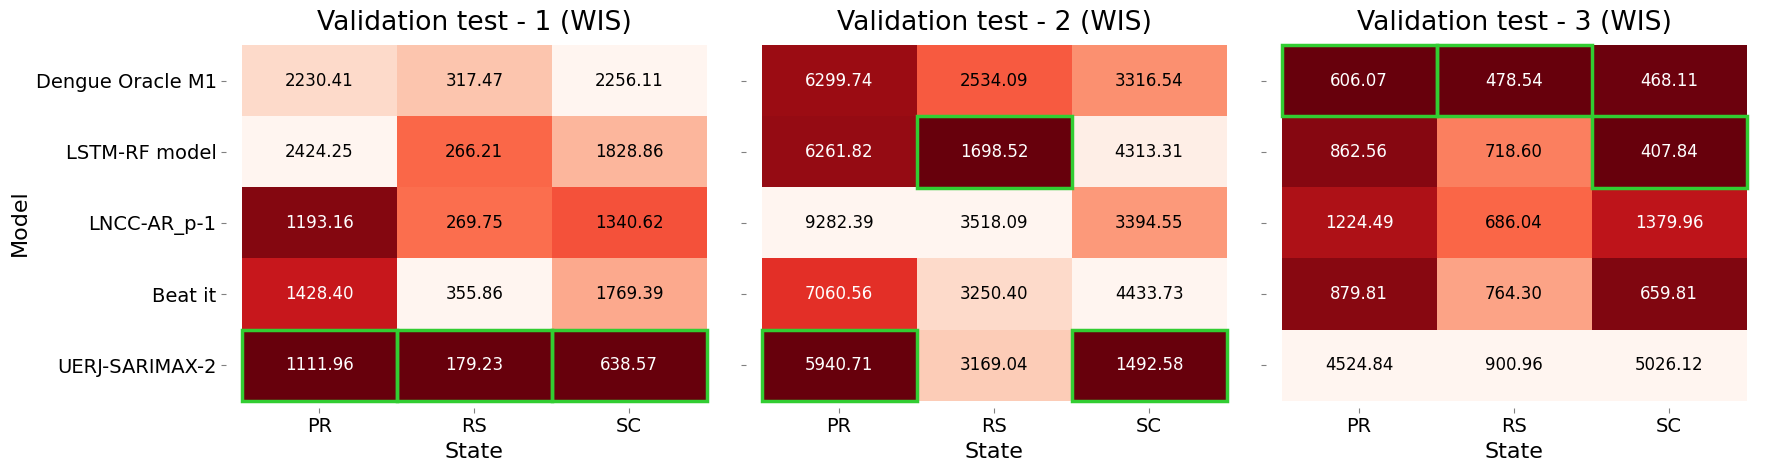

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/11860109.py:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


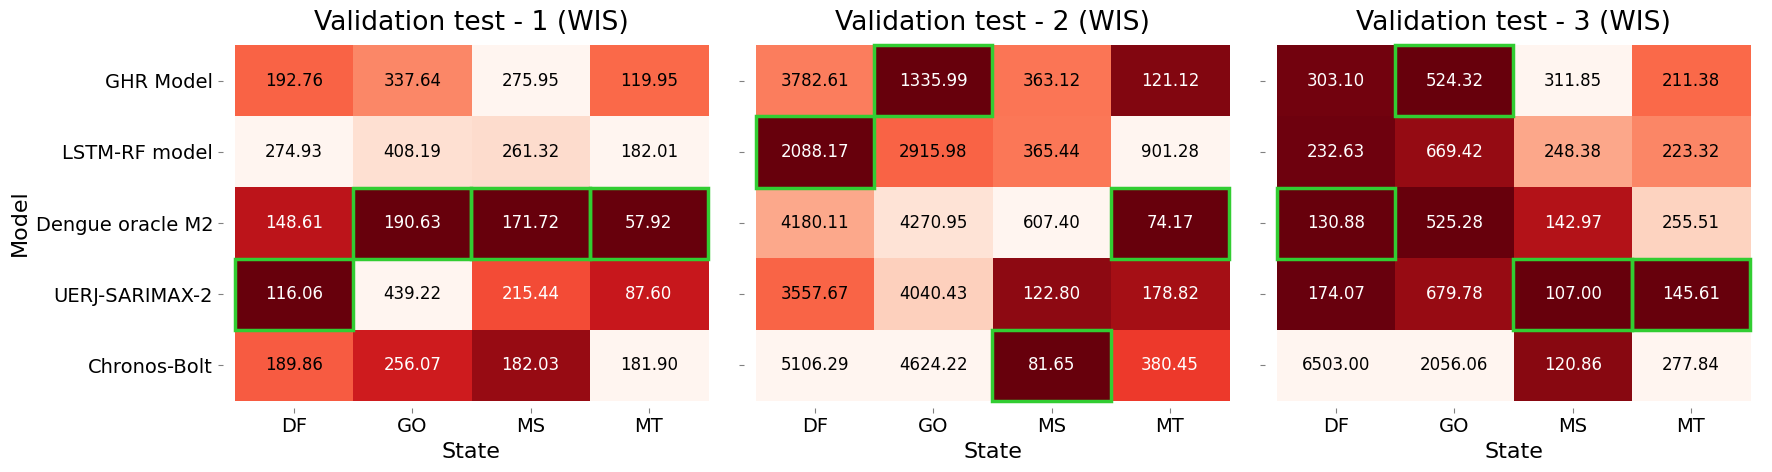

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/11860109.py:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


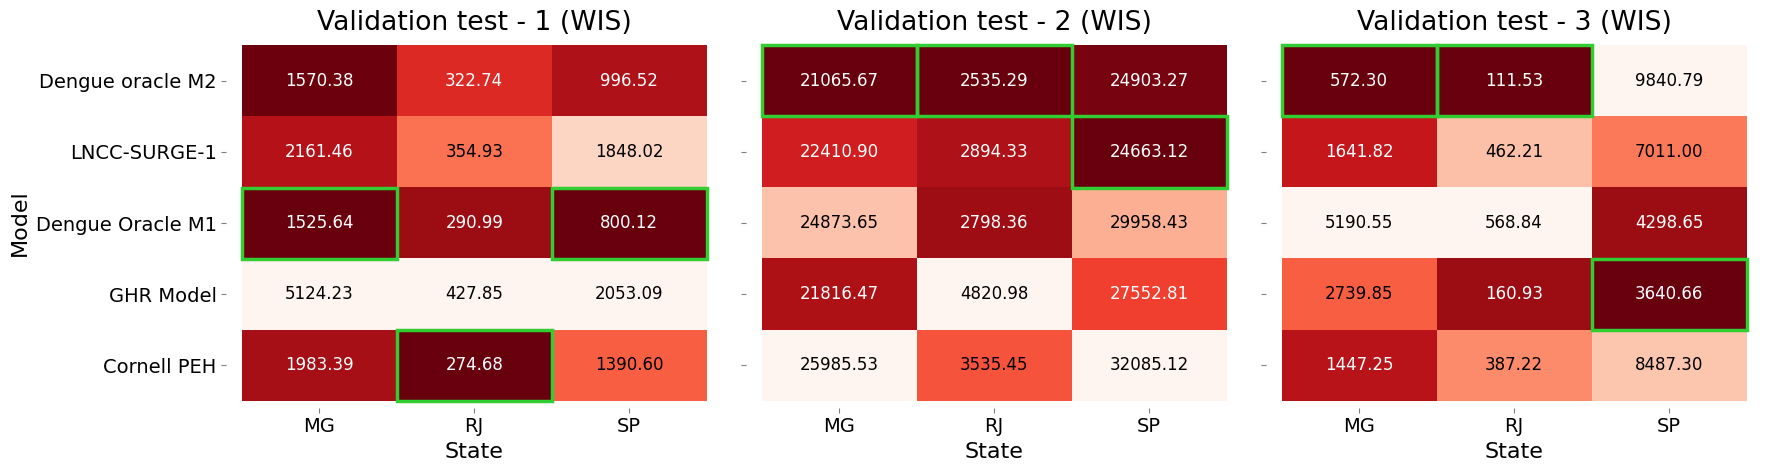

In [25]:
for reg in ['South', 'Midwest', 'Southeast']: 
    
    states = brazil_macroregions[reg]

    top_5_models = get_best_models_region_all(df_metrics, states, n_models = 5)

    #n_models_region = get_best_models_region(df_metrics, states, validation_tests, n_models = 20)

    df_sm = order_dataframe(df_metrics, top_5_models)
    df_sm['model'] = df_sm['model'].replace(dict_models_name)


    _,ax = plt.subplots(1,3, figsize = (18, 5), sharey = True)

    plot_heat(ax[0], df_sm.loc[(df_sm.validation_test == '1') & (df_sm.state.isin(states))], '1', 'WIS', 'Validation test')
    
    plot_heat(ax[1], df_sm.loc[(df_sm.validation_test == '2') & (df_sm.state.isin(states))], '2', 'WIS', 'Validation test')
    
    plot_heat(ax[2], df_sm.loc[(df_sm.validation_test == '3') & (df_sm.state.isin(states))], '3', 'WIS', 'Validation test')

    ax[1].set_ylabel('')
    ax[2].set_ylabel('')
    plt.tight_layout()

    plt.savefig(f'figures/top_5_WIS_{reg.lower()}.png', dpi = 400, bbox_inches = 'tight')

    plt.show()

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/3405706369.py:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


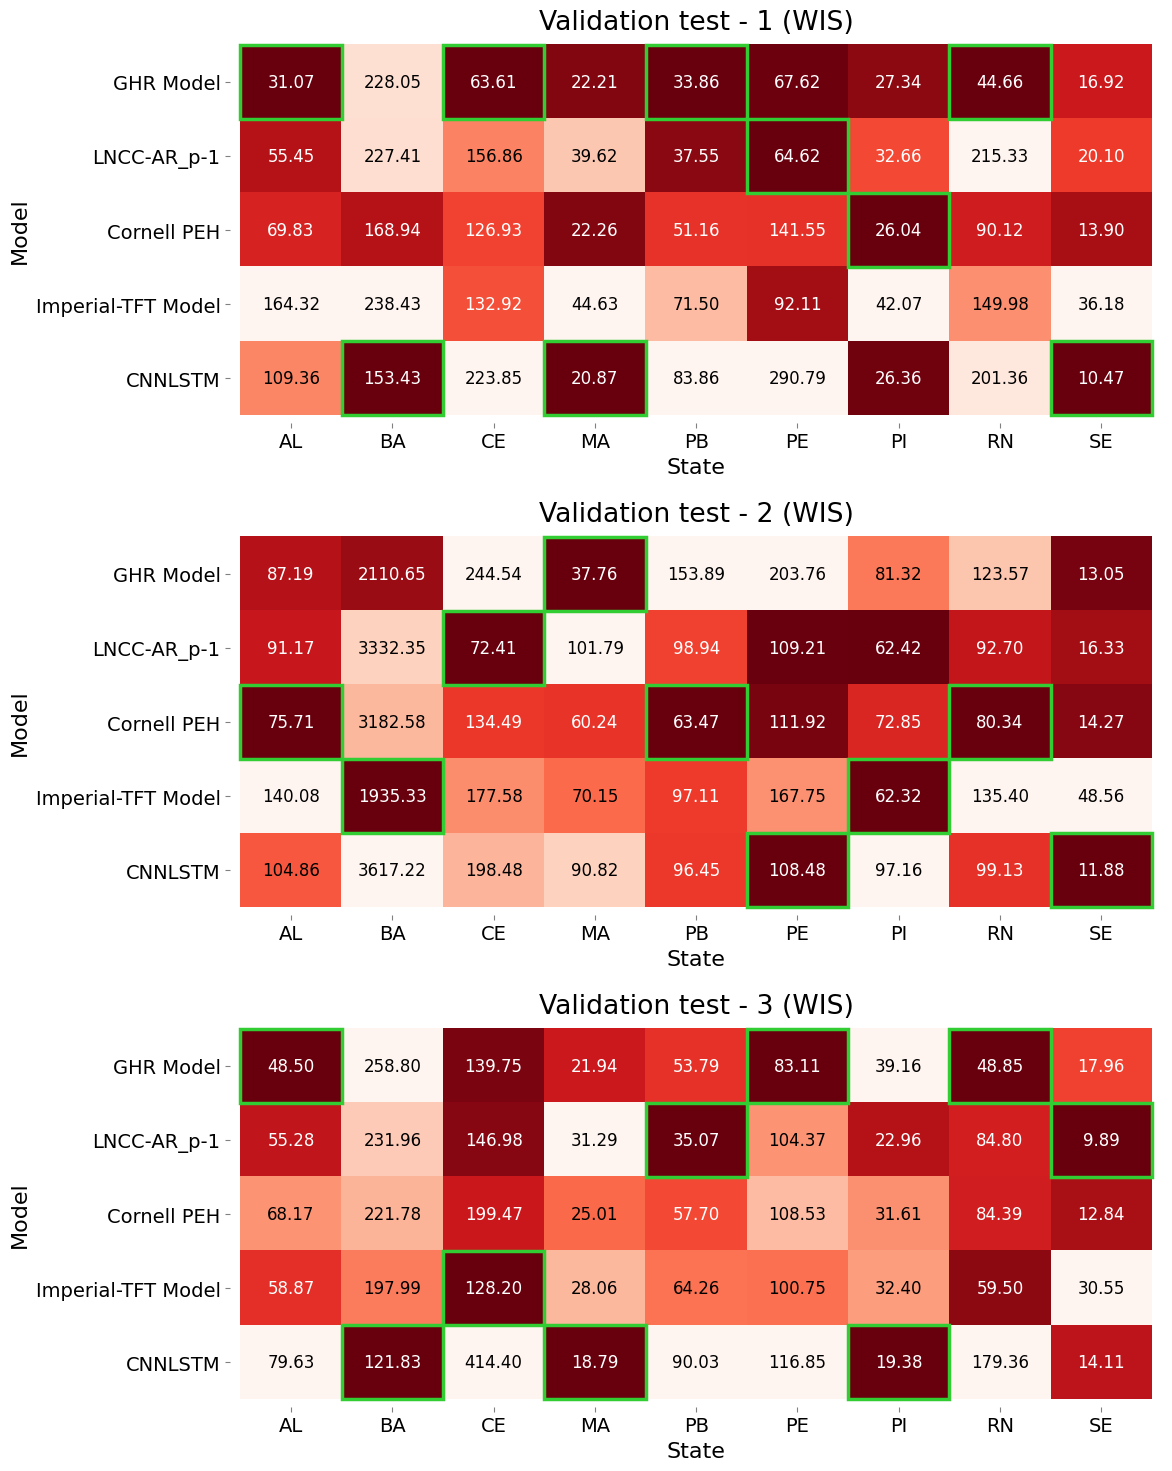

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_73898/3405706369.py:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


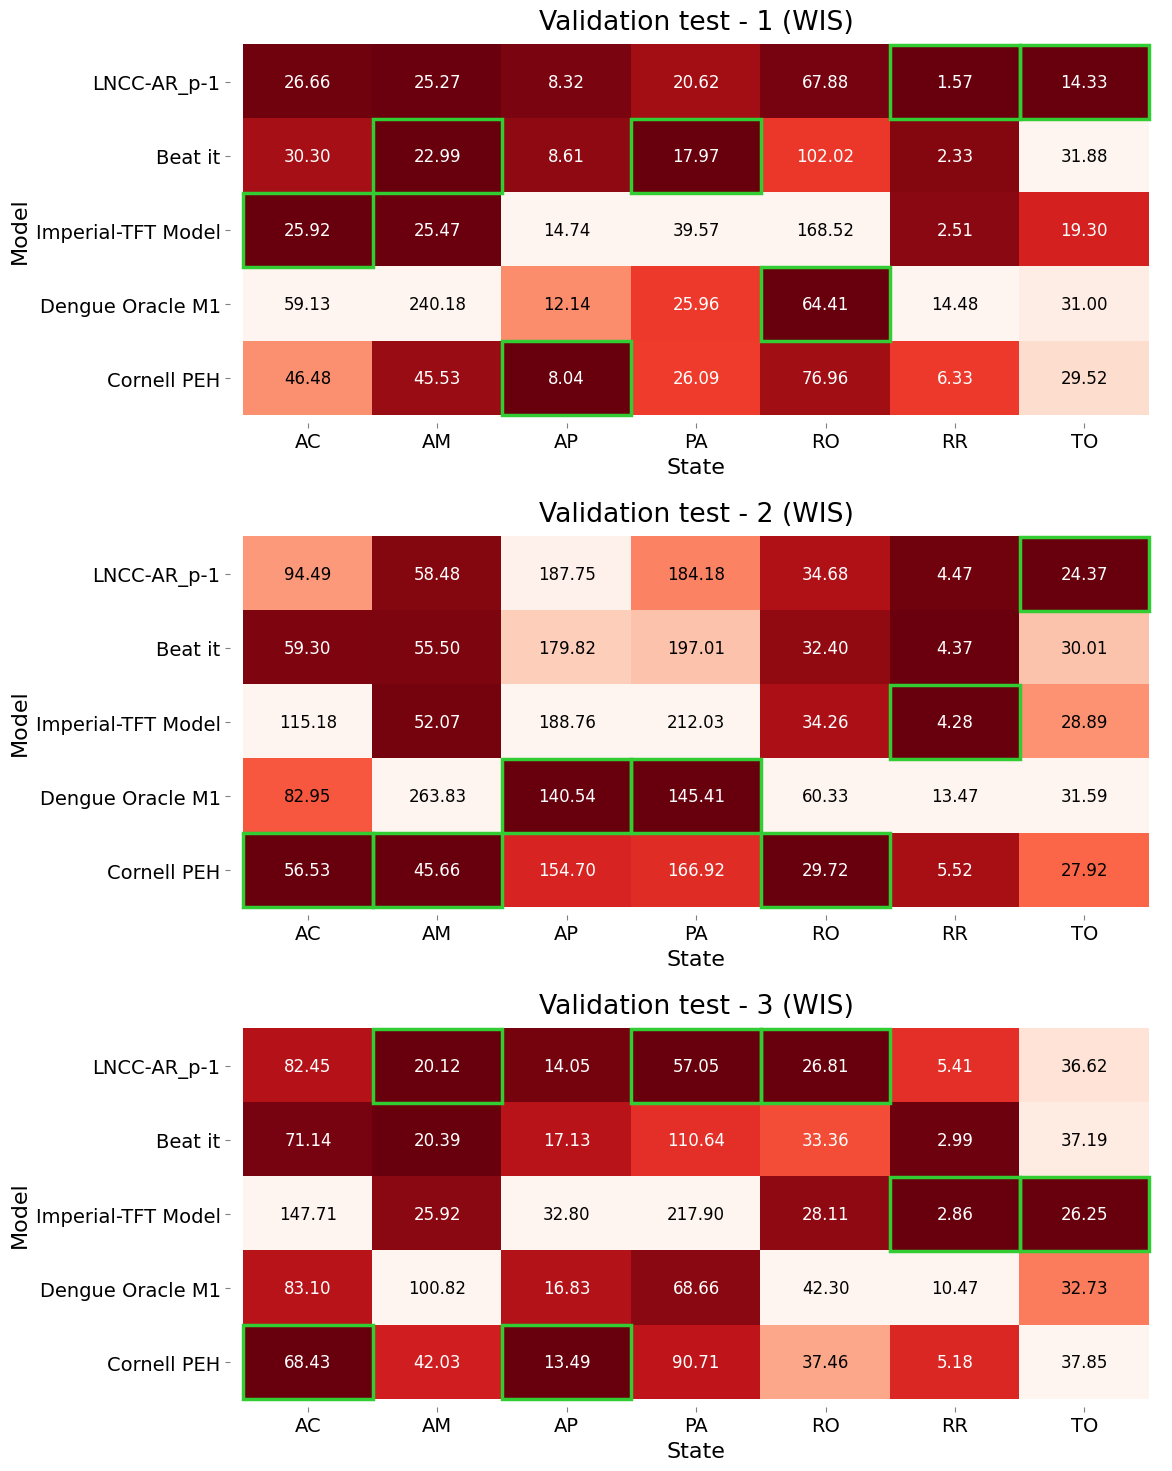

In [26]:
for reg in ['Northeast', 'North']: 
    
    states = brazil_macroregions[reg]

    top_5_models = get_best_models_region_all(df_metrics, states, n_models = 5)

    #n_models_region = get_best_models_region(df_metrics, states, validation_tests, n_models = 20)

    df_sm = order_dataframe(df_metrics, top_5_models)
    df_sm['model'] = df_sm['model'].replace(dict_models_name)

    _,ax = plt.subplots(3, 1, figsize = (12, 15))

    plot_heat(ax[0], df_sm.loc[(df_sm.validation_test == '1') & (df_sm.state.isin(states))], '1', 'WIS', 'Validation test')
    
    plot_heat(ax[1], df_sm.loc[(df_sm.validation_test == '2') & (df_sm.state.isin(states))], '2', 'WIS', 'Validation test')
    
    plot_heat(ax[2], df_sm.loc[(df_sm.validation_test == '3') & (df_sm.state.isin(states))], '3', 'WIS', 'Validation test')

    plt.tight_layout()
    plt.savefig(f'figures/top_5_WIS_{reg.lower()}.png', dpi = 400, bbox_inches = 'tight')

    plt.show()

### Scores in predicting the peak week

In [27]:
df_metrics_peak = df_metrics.groupby(['model', 'state'])[['WIS_peak']].mean().reset_index()

df_metrics_peak['validation_test'] = 'all' 

df_metrics_peak.head()

,model,state,WIS_peak,validation_test
0,108,AC,220.487896,all
1,108,AL,956.702767,all
2,108,AM,81.679109,all
3,108,AP,258.174711,all
4,108,BA,4584.765438,all


In [28]:
df_reg = pd.DataFrame()

for reg in dict_regions.keys(): 
    
    df_reg[reg] = get_best_models_region_all(df_metrics_peak, 
                                         dict_regions[reg], 
                                         n_models = 5, column = 'WIS_peak').values
df_reg = df_reg.replace(dict_models_name)
df_reg.head()

,Nordeste,Sudeste,Sul,Centro-Oeste,Norte
0,GHR Model,IMPA-TECH,LSTM-RF model,GHR Model,Dengue oracle M2
1,Dengue oracle M2,GHR Model,Beat it,LSTM-RF model,Cornell PEH
2,LNCC-AR_p-1,LNCC-SURGE-1,UERJ-SARIMAX-2,Chronos-Bolt,Model fourier-\n gravidade
3,Dengue Oracle M1,Dengue oracle M2,LNCC-SURGE-1,UERJ-SARIMAX-2,Dengue Oracle M1
4,Imperial-TFT Model,Dengue Oracle M1,Dengue Oracle M1,Dengue Oracle M1,Imperial-TFT Model


In [29]:
df_reg.to_csv('results/best_region_models_peak.csv', index = False)

### Scores total cases: 

In [28]:
df_metrics_total = pd.read_csv('results/metrics_total_cases.csv')
df_metrics_total = df_metrics_total.rename(columns = {'valid_test': 'validation_test', 
                                                      'model_id': 'model'})
df_metrics_total['validation_test'] = df_metrics_total['validation_test'].astype(str)
df_metrics_total.head()

,model,state,validation_test,WIS
0,108,RS,3,1.482976e+07
1,133,RS,3,3.159015e+05
2,134,RS,3,5.072076e+05
3,135,RS,3,5.516734e+04
4,136,RS,3,3.599041e+04


In [29]:
df_metrics_rank_total = df_metrics_total.groupby(['model', 'state'])[['WIS']].mean().reset_index()

df_metrics_rank_total['validation_test'] = 'all' 

df_metrics_rank_total.head()

,model,state,WIS,validation_test
0,108,AC,16256.914318,all
1,108,AL,106438.564392,all
2,108,AM,2574.275703,all
3,108,AP,15879.739953,all
4,108,BA,129753.674775,all


#### Ranking: 

By state: 

In [30]:
df_s = df_metrics_rank_total.loc[df_metrics_rank_total.groupby("state")["WIS"].idxmin()][['model', 'state']].rename(columns = {'model':'best_model'})

df_s.head()

,best_model,state
78,135,AC
79,135,AL
106,136,AM
211,143,AP
134,137,BA


By macroregion:

In [31]:
df_reg_total = pd.DataFrame()

for reg in dict_regions.keys(): 
    
    df_reg_total[reg] = get_best_models_region_all(df_metrics_rank_total, 
                                         dict_regions[reg], 
                                         n_models = 5, column = 'WIS').values
df_reg_total = df_reg_total.replace(dict_models_name)
df_reg_total.head()

,Nordeste,Sudeste,Sul,Centro-Oeste,Norte
0,Cornell PEH,Dengue oracle M2,LSTM-RF model,LSTM-RF model,Imperial-TFT Model
1,LNCC-CLIDENGO-1,LSTM-RF model,LNCC-SURGE-1,GHR Model,Cornell PEH
2,GHR Model,Dengue Oracle M1,Dengue Oracle M1,ISI_Dengue_Model,Model fourier-\n gravidade
3,Imperial-TFT Model,LNCC-SURGE-1,Dengue oracle M2,Imperial-TFT Model,GHR Model
4,Model fourier-\n gravidade,GHR Model,ISI_Dengue_Model,UERJ-SARIMAX-2,LNCC-AR_p-1


In [32]:
df_reg_total.to_csv('results/best_region_models_total.csv', index = False)

Plot the scores: 

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_15433/1479918424.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


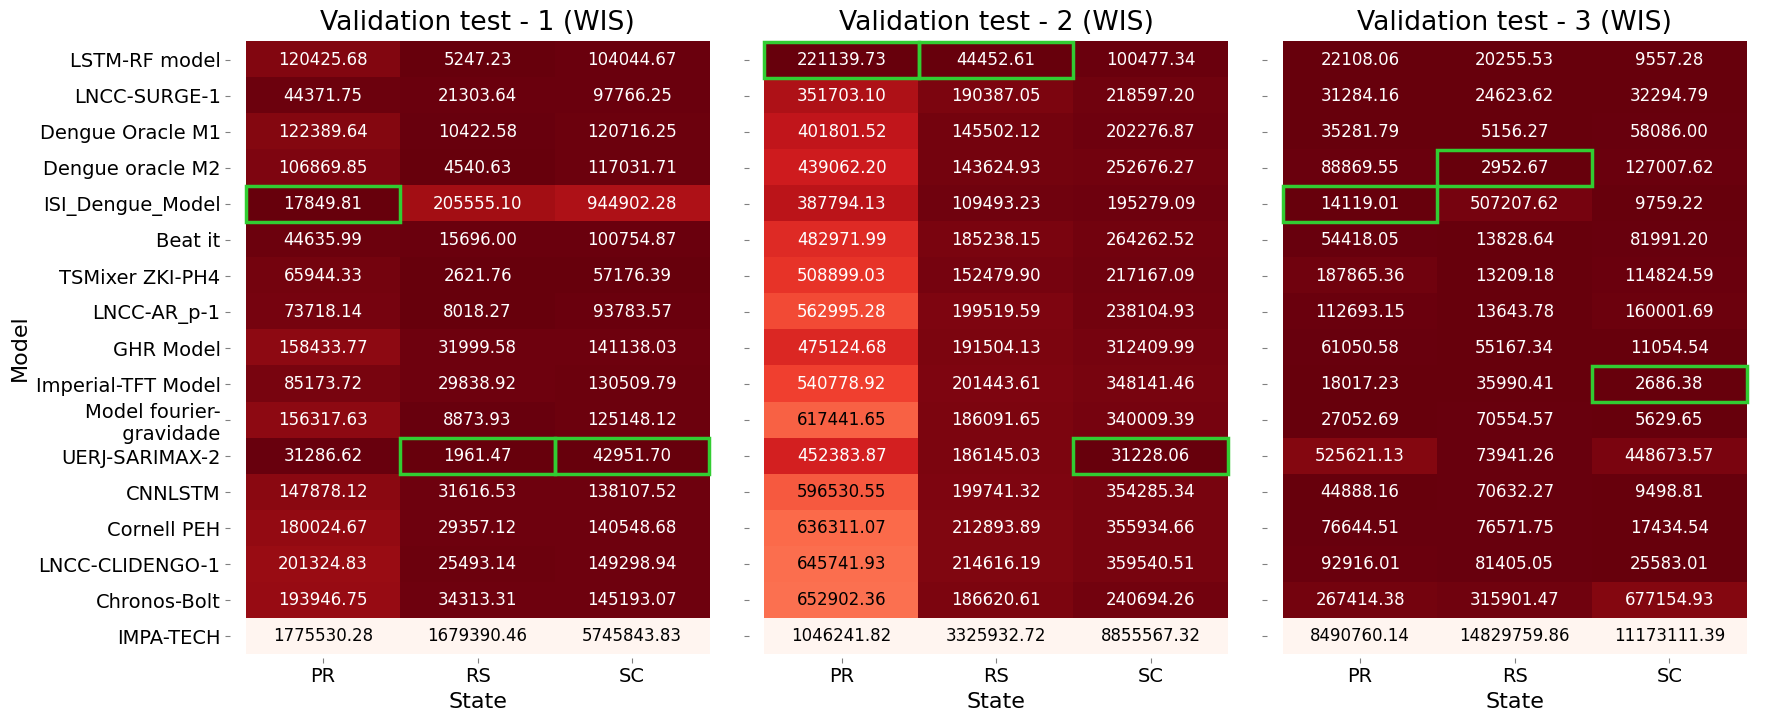

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_15433/1479918424.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


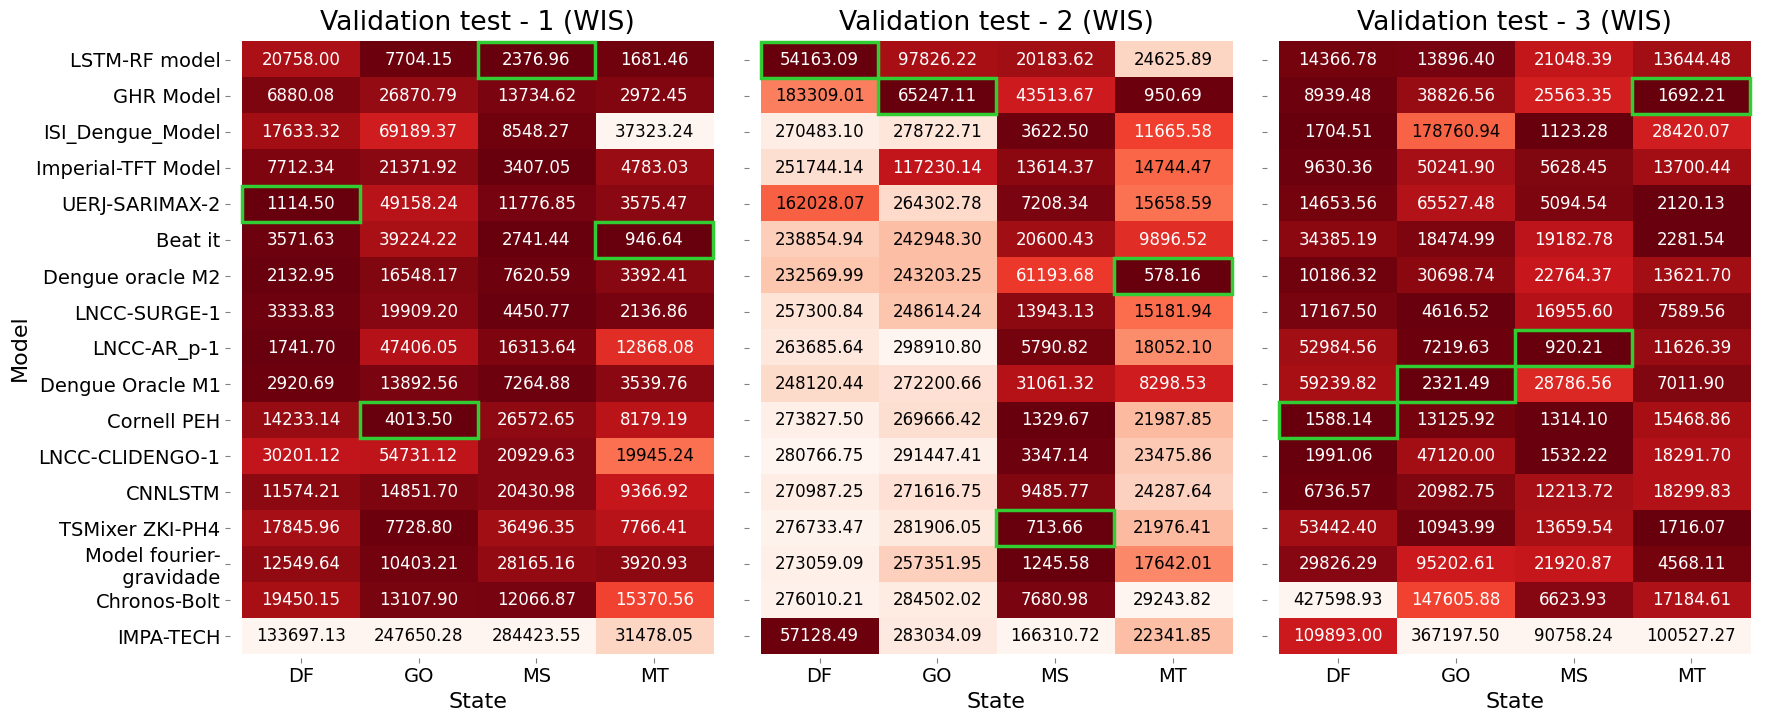

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_15433/1479918424.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


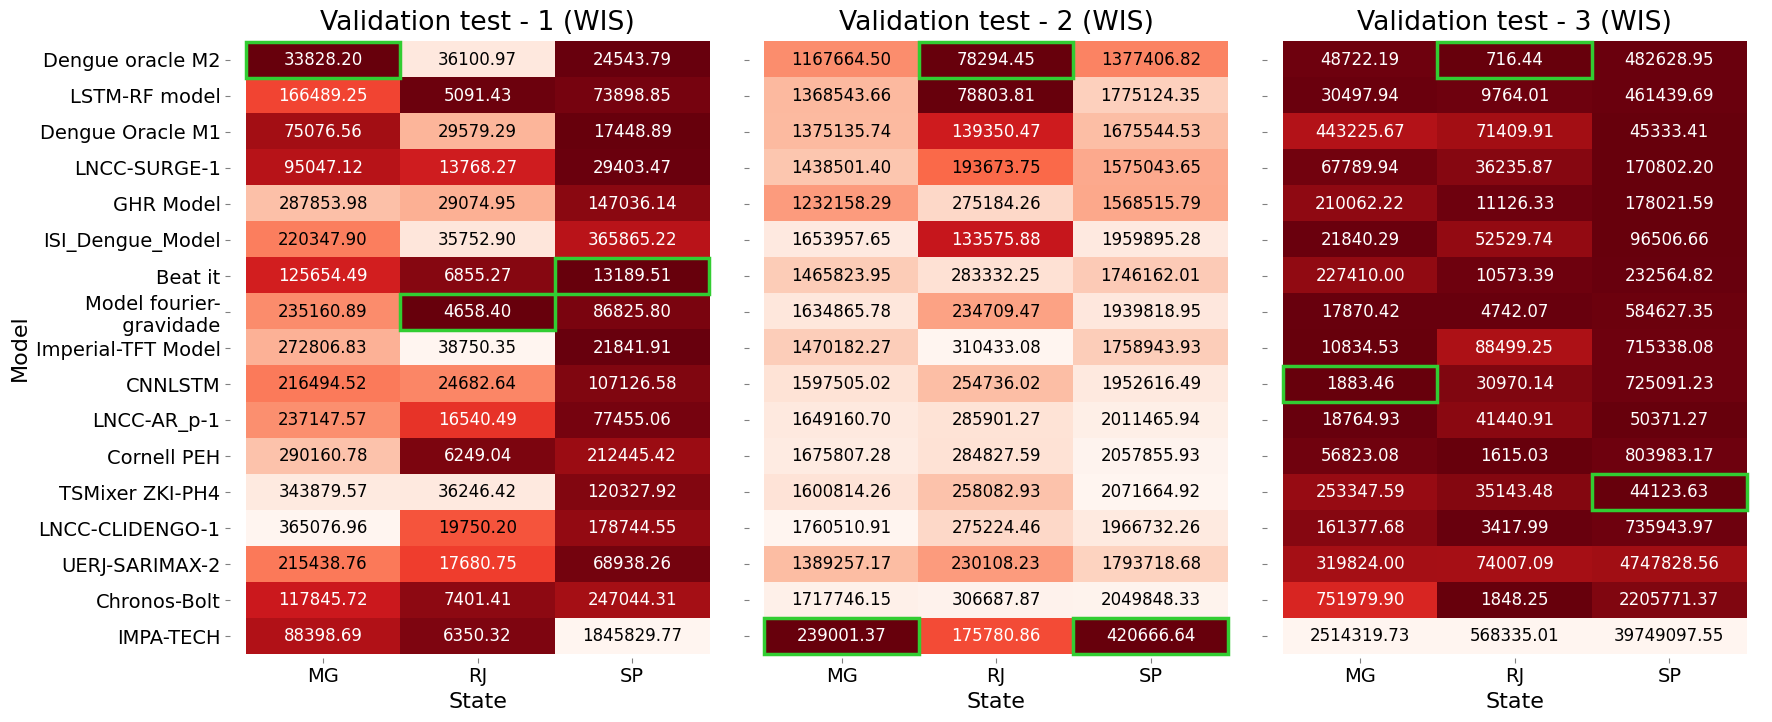

In [33]:
validation_tests = ['1', '2', '3']

for reg in ['South', 'Midwest', 'Southeast']: 
    
    states = brazil_macroregions[reg]

    #n_models_region = get_best_models_region(df_metrics_total, states, validation_tests, n_models = 20, columns = ['WIS'])
    n_models_region = get_best_models_region_all(df_metrics_rank_total, 
                                         states, 
                                         n_models = 20, column = 'WIS')
    
    df_sm = order_dataframe(df_metrics_total, n_models_region)
    df_sm['model'] = df_sm['model'].replace(dict_models_name)


    _,ax = plt.subplots(1,3, figsize = (18, 7.5), sharey =True)

    plot_heat(ax[0], df_sm.loc[(df_sm.validation_test == '1') & (df_sm.state.isin(states))], '1', 'WIS', 'Validation test')
    
    plot_heat(ax[1], df_sm.loc[(df_sm.validation_test == '2') & (df_sm.state.isin(states))], '2', 'WIS', 'Validation test')
    
    plot_heat(ax[2], df_sm.loc[(df_sm.validation_test == '3') & (df_sm.state.isin(states))], '3', 'WIS', 'Validation test')

    ax[1].set_ylabel('')
    ax[2].set_ylabel('')
    plt.tight_layout()

    plt.savefig(f'figures/all_models_total_cases_WIS_{reg.lower()}.png', dpi = 400, bbox_inches = 'tight')

    plt.show()
    
        

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_15433/870766913.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


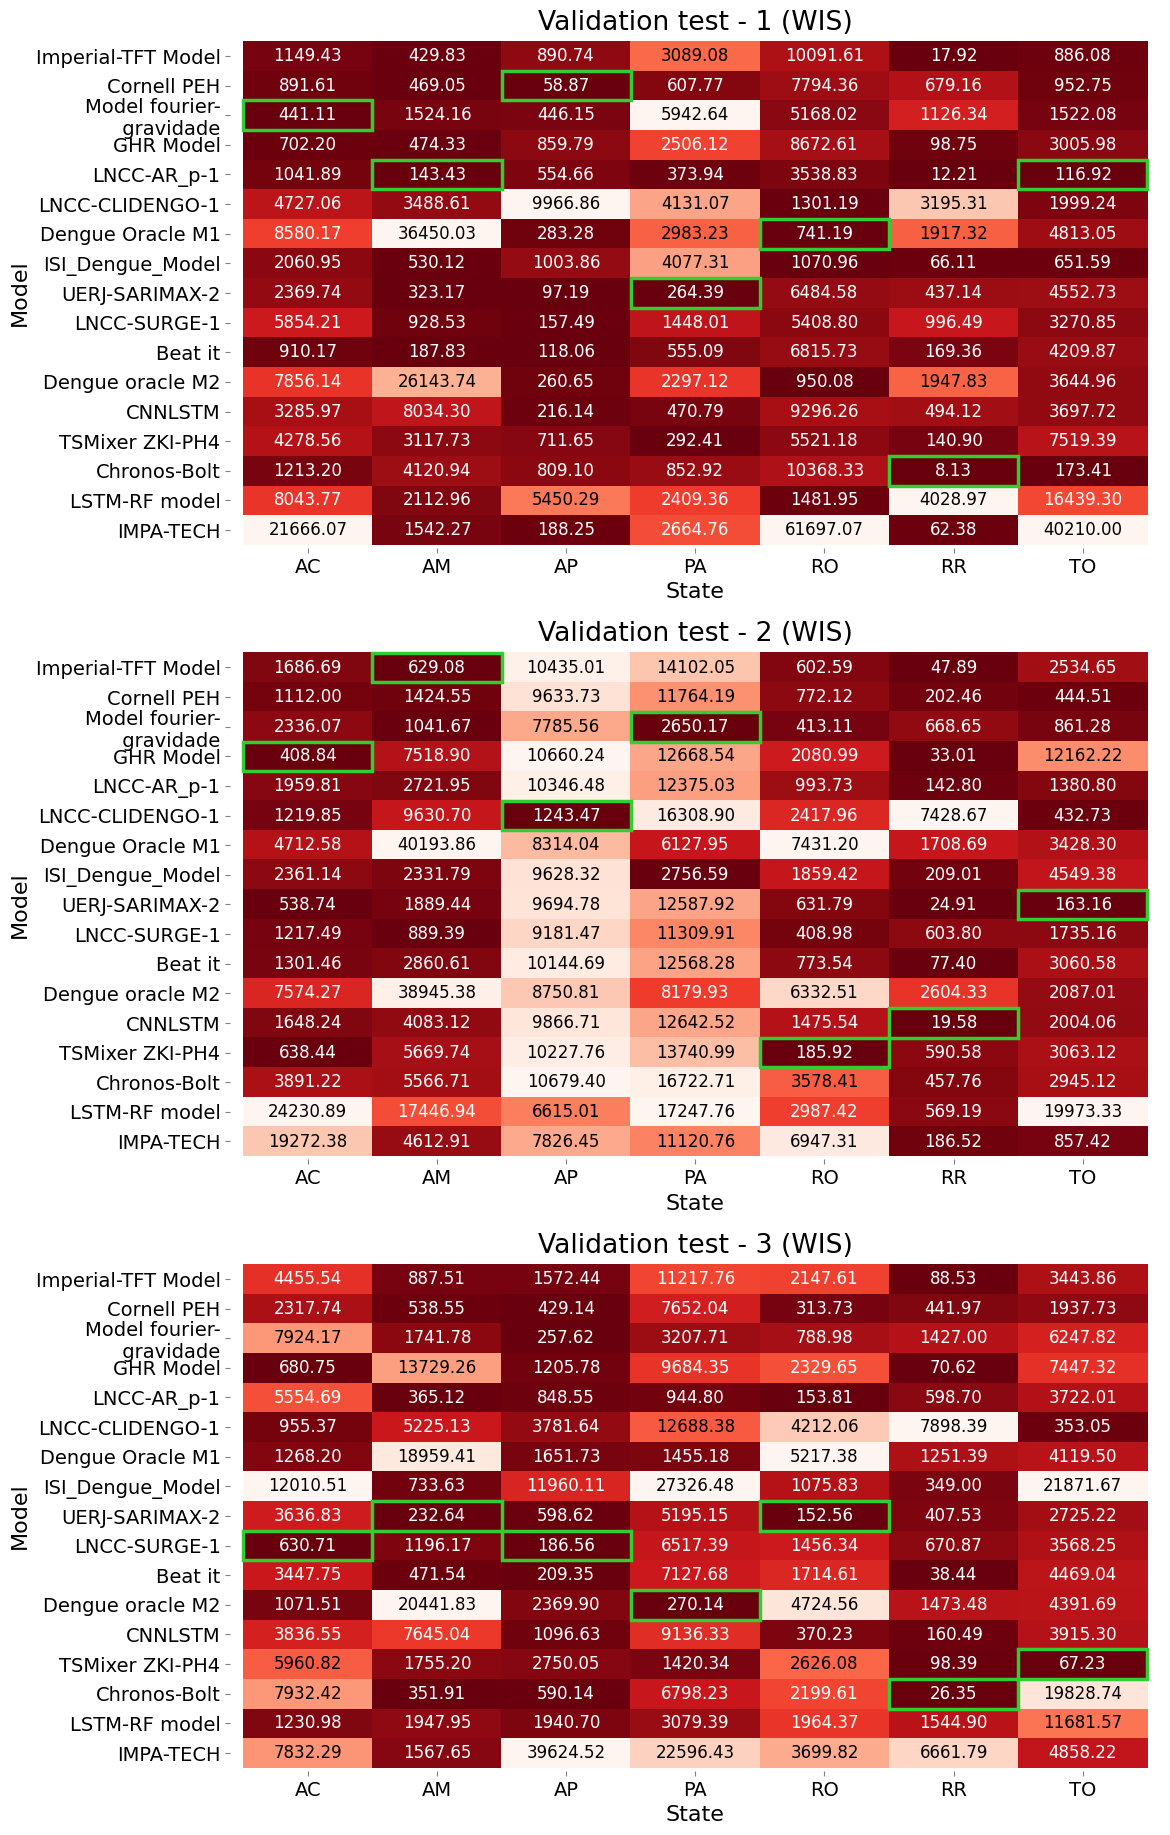

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_15433/870766913.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_sm['model'] = df_sm['model'].replace(dict_models_name)


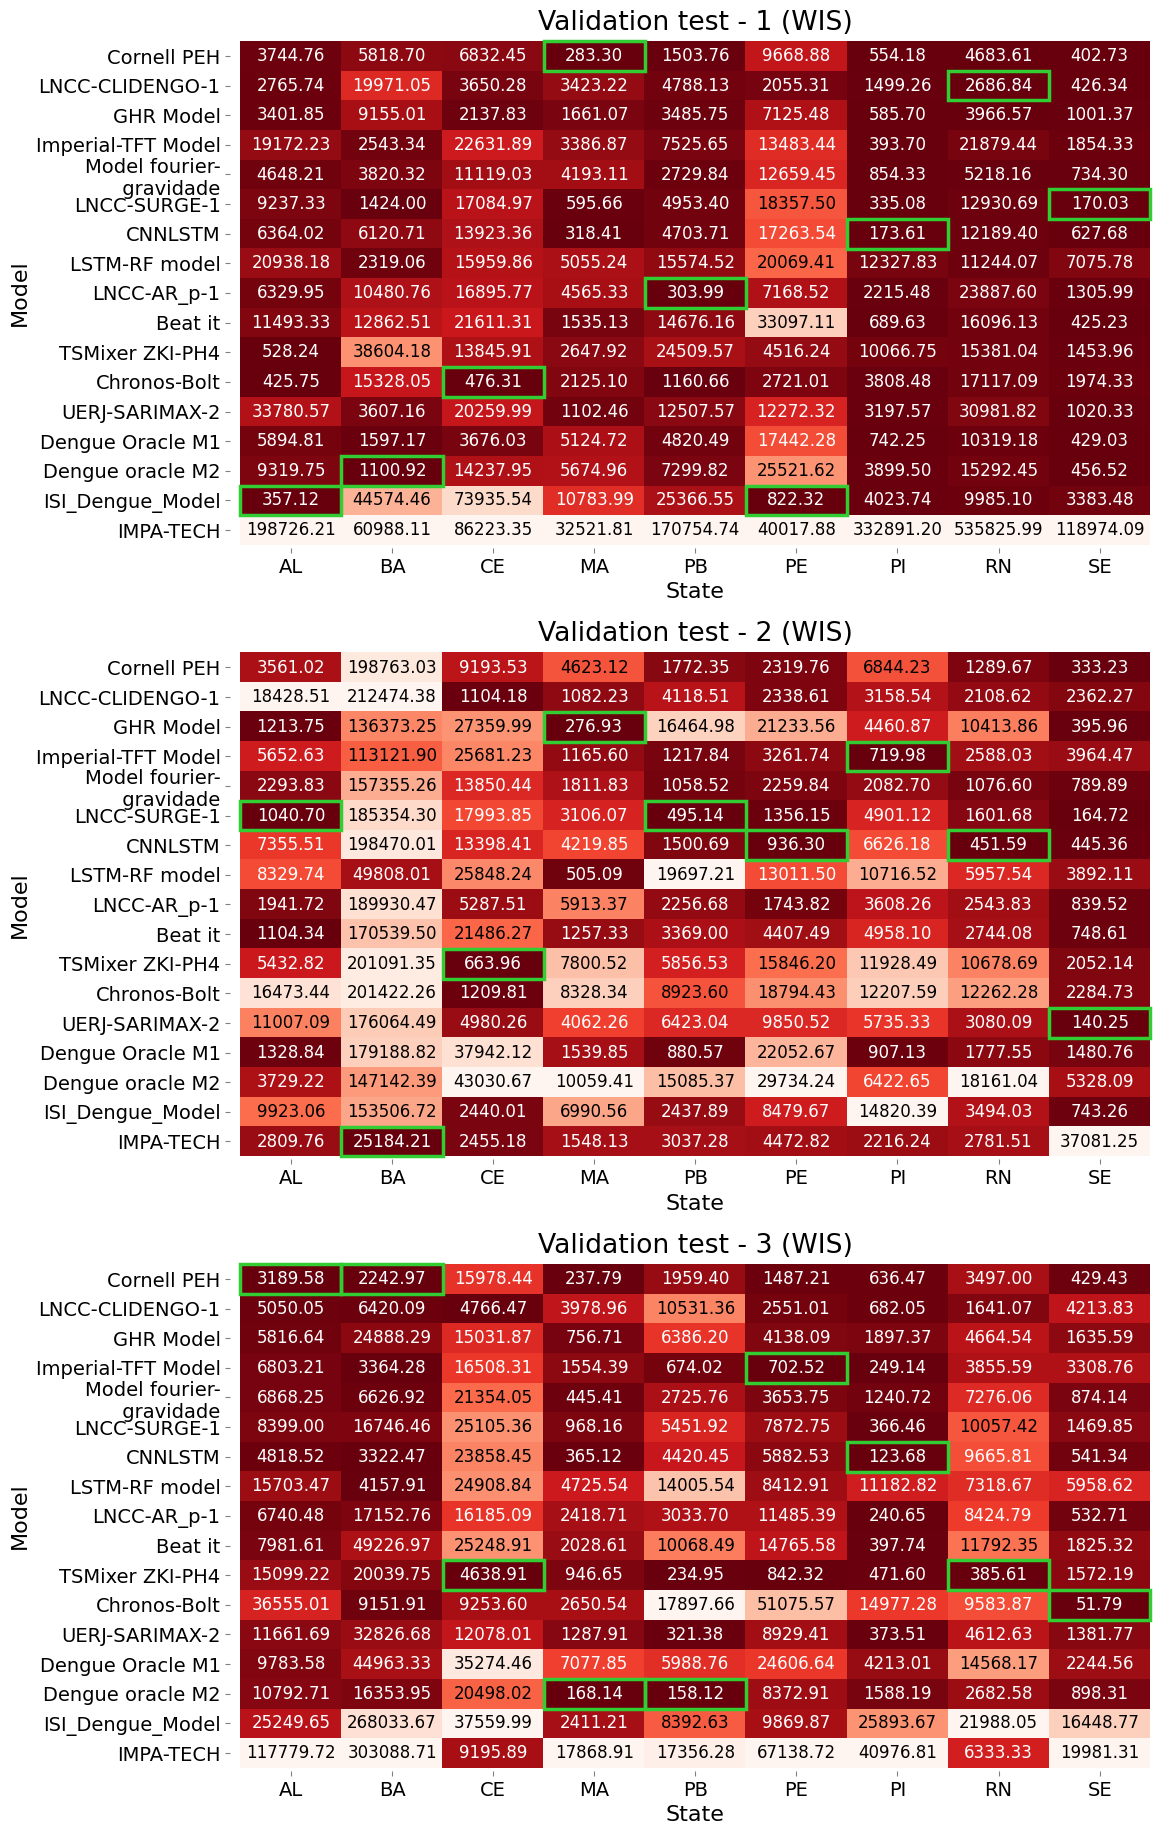

In [34]:
for reg in ['North', 'Northeast']: 
    
    states = brazil_macroregions[reg]

    #n_models_region = get_best_models_region(df_metrics_total, states, validation_tests, n_models = 20, columns = ['WIS'])

    n_models_region = get_best_models_region_all(df_metrics_rank_total, 
                                         states, 
                                         n_models = 20, column = 'WIS')

    df_sm = order_dataframe(df_metrics_total, n_models_region)
    df_sm['model'] = df_sm['model'].replace(dict_models_name)

    _,ax = plt.subplots(3, 1, figsize = (12, 22.5))

    plot_heat(ax[0], df_sm.loc[(df_sm.validation_test == '1') & (df_sm.state.isin(states))], '1', 'WIS', 'Validation test')
    
    plot_heat(ax[1], df_sm.loc[(df_sm.validation_test == '2') & (df_sm.state.isin(states))], '2', 'WIS', 'Validation test')
    
    plot_heat(ax[2], df_sm.loc[(df_sm.validation_test == '3') & (df_sm.state.isin(states))], '3', 'WIS', 'Validation test')
    
    plt.savefig(f'figures/all_models_total_cases_WIS_{reg.lower()}.png', dpi = 400, bbox_inches = 'tight')

    plt.show()